# Notebook 12: Wilson Loops and Confinement

**Learning objectives:**
- Understand Wilson loops $W(R,T)$ as probes of quark confinement
- Compute Wilson loops from gauge links
- Extract the static quark-antiquark potential $V(R)$
- Observe the area law (confinement) vs perimeter law (deconfinement)
- Understand the string tension and its physical meaning

**Prerequisites:** Notebooks 03-04 (gauge fields, Monte Carlo)

**Reference:** K.G. Wilson, "Confinement of Quarks", Phys. Rev. D 10, 2445 (1974)

In [1]:
from notebook_utils import setup_paths, quick_metropolis
setup_paths()

import numpy as np
import matplotlib.pyplot as plt
import su2

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. What is a Wilson Loop?

A **Wilson loop** $W(R, T)$ is the trace of the path-ordered product of
gauge links around a closed rectangle of spatial extent $R$ and temporal
extent $T$:

$$W(R,T) = \frac{1}{N_c}\mathrm{Re}\,\mathrm{Tr}\left[
\prod_{n=0}^{R-1} U_x(n,0) \cdot
\prod_{n=0}^{T-1} U_t(R,n) \cdot
\prod_{n=R-1}^{0} U_x^\dagger(n,T) \cdot
\prod_{n=T-1}^{0} U_t^\dagger(0,n)
\right]$$

The plaquette is the simplest Wilson loop: $W(1,1)$ (the elementary
$1 \times 1$ Wilson loop, defined as the gauge-invariant ordered product
of four links — see High Energy Physics Essentials Eq. 10.37 and the surrounding
discussion in §10.2).

Wilson loops probe the force between a static quark-antiquark pair
separated by distance $R$, observed over Euclidean time $T$
(Wilson 1974; see also Creutz Ch. 13 for the strong-coupling expansion
of these loops).

## 2. Wilson Loop and Confinement

For large $T$, the Wilson loop decays exponentially:
$$\langle W(R,T) \rangle \xrightarrow{T \to \infty} e^{-V(R) \cdot T}$$

where $V(R)$ is the **static quark-antiquark potential**
(High Energy Physics Essentials Eq. 10.51).

Two scenarios:
- **Confinement** (area law): $V(R) = \sigma R + \ldots$ (linear potential,
  Eq. 10.52 in High Energy Physics Essentials)
  $\Rightarrow$ $\langle W \rangle \sim e^{-\sigma R T} = e^{-\sigma \cdot \text{Area}}$
  (Eq. 10.48; the area law was Wilson's original confinement criterion,
  Wilson 1974)
- **Deconfinement** (perimeter law): $V(R) \to \text{const}$ for large $R$
  $\Rightarrow$ $\langle W \rangle \sim e^{-c \cdot \text{Perimeter}}$

The **string tension** $\sigma$ measures the force per unit length of the
flux tube (color string) between the quark and antiquark.

In [2]:
def compute_wilson_loop_su2(U, La, mups, start_site, R, T, mu_space=0, mu_time=3):
    """Compute a single R x T Wilson loop at a given starting site.
    
    Parameters
    ----------
    U : ndarray, shape (V, 4, 4)
        Gauge field (SU(2) quaternion format).
    La : list
        Lattice dimensions.
    mups : ndarray
        Precomputed forward neighbor table.
    start_site : int
        Starting site index.
    R : int
        Spatial extent of the loop.
    T : int
        Temporal extent of the loop.
    mu_space : int
        Spatial direction (0, 1, or 2).
    mu_time : int
        Temporal direction (3).
    
    Returns
    -------
    float
        (1/2) * Re Tr(W), normalized to [-1, 1].
    """
    # Build path: bottom (spatial), right (temporal), top (spatial, reversed), left (temporal, reversed)
    
    # Start at start_site, accumulate product
    W = su2.cstart()  # identity
    site = start_site
    
    # Bottom: R steps in +mu_space
    for _ in range(R):
        W = su2.mult(W, U[site][mu_space])
        site = mups[site, mu_space]
    
    # Right side: T steps in +mu_time
    for _ in range(T):
        W = su2.mult(W, U[site][mu_time])
        site = mups[site, mu_time]
    
    # Top: R steps in -mu_space (use dagger of link at neighbor)
    for _ in range(R):
        # Go backward: use U_mu(x-mu)^dagger
        # site is at (start_x + R, start_t + T), need to go -mu_space
        prev_site = su2.mdowni(site, mu_space, La)
        W = su2.mult(W, su2.dag(U[prev_site][mu_space]))
        site = prev_site
    
    # Left side: T steps in -mu_time
    for _ in range(T):
        prev_site = su2.mdowni(site, mu_time, La)
        W = su2.mult(W, su2.dag(U[prev_site][mu_time]))
        site = prev_site
    
    # Should be back at start_site
    assert site == start_site, f"Loop didn't close! Ended at {site}, started at {start_site}"
    
    return 0.5 * su2.tr(W)  # (1/2) Tr for SU(2)

In [3]:
# Generate a thermalized configuration
La = [4, 4, 4, 8]
V = su2.vol(La)
beta = 2.4

print(f"Generating thermalized config on {La} lattice at beta={beta}...")
_, U = quick_metropolis(La, beta=beta, n_sweeps=200, start='cold', seed=42)

mups = su2.getMups(V, len(La), La)
mdns = su2.getMdns(V, len(La), La)

# Verify plaquette = W(1,1)
plaq = su2.calcPlaq(U, La, mups)
w11 = np.mean([compute_wilson_loop_su2(U, La, mups, i, 1, 1)
               for i in range(V)])
print(f"Average plaquette: {plaq:.6f}")
print(f"Average W(1,1):    {w11:.6f}")
print(f"Agreement: {abs(plaq - w11) < 0.01}")

Generating thermalized config on [4, 4, 4, 8] lattice at beta=2.4...


  Sweep 1/200: P = 0.911326


  Sweep 20/200: P = 0.687679


  Sweep 40/200: P = 0.671745


  Sweep 60/200: P = 0.668365


...

  Sweep 140/200: P = 0.674093


  Sweep 160/200: P = 0.702771


  Sweep 180/200: P = 0.712204


  Sweep 200/200: P = 0.709269


Average plaquette: 0.709269
Average W(1,1):    0.711088
Agreement: True


## 3. Measuring Wilson Loops

We average $W(R,T)$ over all starting sites and spatial directions
to reduce noise.

In [4]:
def average_wilson_loop(U, La, mups, R, T):
    """Average W(R,T) over all sites and spatial directions."""
    V = su2.vol(La)
    values = []
    for site in range(V):
        for mu_s in range(3):  # spatial directions 0, 1, 2
            w = compute_wilson_loop_su2(U, La, mups, site, R, T,
                                        mu_space=mu_s, mu_time=3)
            values.append(w)
    return np.mean(values), np.std(values) / np.sqrt(len(values))

# Compute W(R,T) for several R and T
R_max = min(La[0]//2, 3)
T_max = min(La[3]//2, 5)

print(f"Computing Wilson loops up to R={R_max}, T={T_max}...")
W_vals = np.zeros((R_max, T_max))
W_errs = np.zeros((R_max, T_max))

for R in range(1, R_max + 1):
    for T in range(1, T_max + 1):
        mean, err = average_wilson_loop(U, La, mups, R, T)
        W_vals[R-1, T-1] = mean
        W_errs[R-1, T-1] = err
        print(f"  W({R},{T}) = {mean:.6f} +/- {err:.6f}")

Computing Wilson loops up to R=2, T=4...


  W(1,1) = 0.716377 +/- 0.007381


  W(1,2) = 0.521741 +/- 0.010510


  W(1,3) = 0.410417 +/- 0.012478


  W(1,4) = 0.315724 +/- 0.014206
  W(2,1) = 0.526834 +/- 0.010608


  W(2,2) = 0.335045 +/- 0.013122


  W(2,3) = 0.248164 +/- 0.014659


  W(2,4) = 0.192865 +/- 0.015346


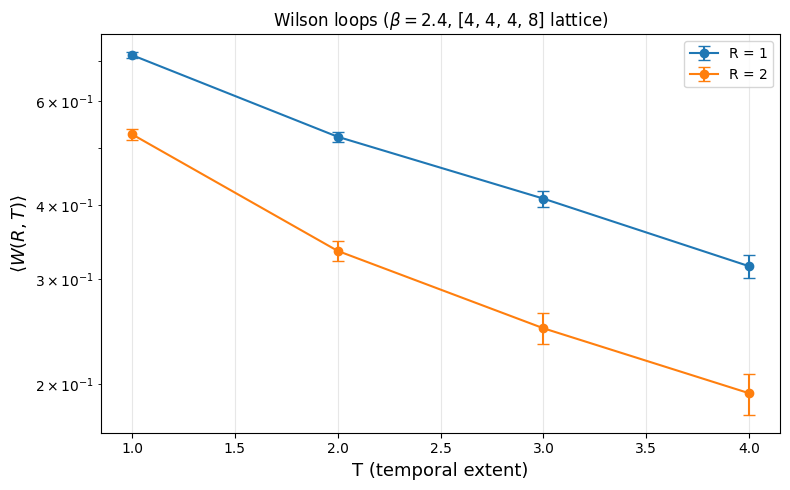

In [5]:
# Plot W(R,T) vs T for different R
fig, ax = plt.subplots(figsize=(8, 5))

for R in range(1, R_max + 1):
    T_range = np.arange(1, T_max + 1)
    ax.errorbar(T_range, W_vals[R-1, :], yerr=W_errs[R-1, :],
                fmt='o-', capsize=4, markersize=6, label=f'R = {R}')

ax.set_xlabel('T (temporal extent)', fontsize=13)
ax.set_ylabel(r'$\langle W(R,T) \rangle$', fontsize=13)
ax.set_title(f'Wilson loops ($\\beta = {beta}$, {La} lattice)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Static Potential $V(R)$

From $\langle W(R,T) \rangle \sim e^{-V(R)T}$ (High Energy Physics Essentials Eq. 10.51),
we extract:

$$V(R) = -\frac{1}{a_t} \ln\frac{\langle W(R,T+1)\rangle}{\langle W(R,T)\rangle}$$

at large enough $T$ for the ground state to dominate.

In [6]:
# Extract V(R) from ratio of consecutive T values
# Use T and T+1 where signal is still good
T_fit = min(2, T_max - 1)  # use T=T_fit and T=T_fit+1

V_R = []
V_R_err = []
R_vals = list(range(1, R_max + 1))

print(f"Extracting V(R) from W(R,T={T_fit})/W(R,T={T_fit+1}):")
for R in R_vals:
    w1 = W_vals[R-1, T_fit-1]
    w2 = W_vals[R-1, T_fit]
    if w1 > 0 and w2 > 0:
        V = -np.log(w2 / w1)
        # Simple error propagation
        e1 = W_errs[R-1, T_fit-1]
        e2 = W_errs[R-1, T_fit]
        V_err = np.sqrt((e1/w1)**2 + (e2/w2)**2)
        V_R.append(V)
        V_R_err.append(V_err)
        print(f"  V(R={R}) = {V:.4f} +/- {V_err:.4f}")
    else:
        V_R.append(np.nan)
        V_R_err.append(np.nan)
        print(f"  V(R={R}) = N/A (negative Wilson loop)")

V_R = np.array(V_R)
V_R_err = np.array(V_R_err)

Extracting V(R) from W(R,T=2)/W(R,T=3):
  V(R=1) = 0.2400 +/- 0.0365
  V(R=2) = 0.3002 +/- 0.0709


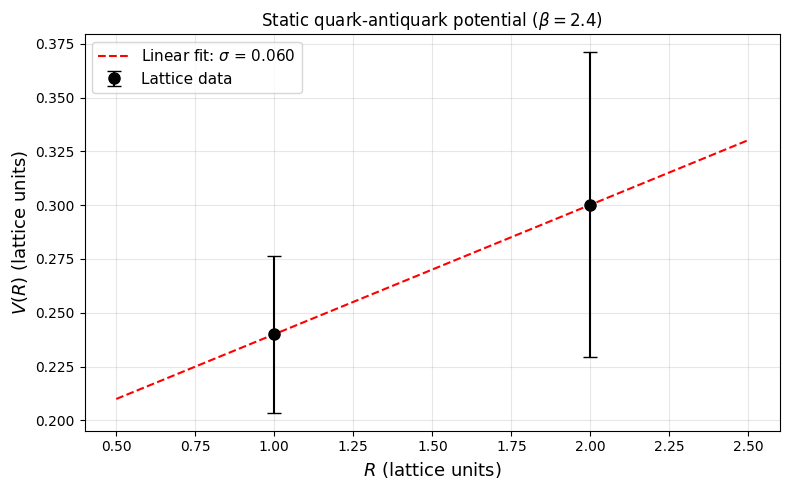


String tension: sigma = 0.0602 (lattice units)
This means the potential grows linearly with distance -> confinement!


In [7]:
# Plot the static potential
fig, ax = plt.subplots(figsize=(8, 5))

valid = np.isfinite(V_R)
R_arr = np.array(R_vals)
ax.errorbar(R_arr[valid], V_R[valid], yerr=V_R_err[valid],
            fmt='ko', capsize=5, markersize=8, label='Lattice data')

# Fit to Cornell potential: V(R) = sigma*R + c (linear part only on small lattice)
if np.sum(valid) >= 2:
    from numpy.polynomial import polynomial as P
    coeffs = np.polyfit(R_arr[valid], V_R[valid], 1)
    sigma = coeffs[0]
    R_fit = np.linspace(0.5, R_max + 0.5, 50)
    ax.plot(R_fit, np.polyval(coeffs, R_fit), 'r--',
            label=f'Linear fit: $\\sigma$ = {sigma:.3f}')

ax.set_xlabel('$R$ (lattice units)', fontsize=13)
ax.set_ylabel('$V(R)$ (lattice units)', fontsize=13)
ax.set_title(f'Static quark-antiquark potential ($\\beta = {beta}$)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if np.sum(valid) >= 2:
    print(f"\nString tension: sigma = {sigma:.4f} (lattice units)")
    print(f"This means the potential grows linearly with distance -> confinement!")

## 5. Area Law vs Perimeter Law

The hallmark of confinement is the **area law**:
$$\ln \langle W(R,T) \rangle \propto -\sigma \cdot R \cdot T$$

If we plot $-\ln W(R,T)$ vs the area $R \times T$, confinement predicts
a straight line with slope $\sigma$ (High Energy Physics Essentials Eq. 10.48; Wilson 1974;
see Creutz Ch. 13 for the strong-coupling derivation showing the area
law arises naturally at large $\beta^{-1}$, and Creutz Ch. 12 for the
gauge-invariance argument that single Wilson lines vanish in a confining
phase).

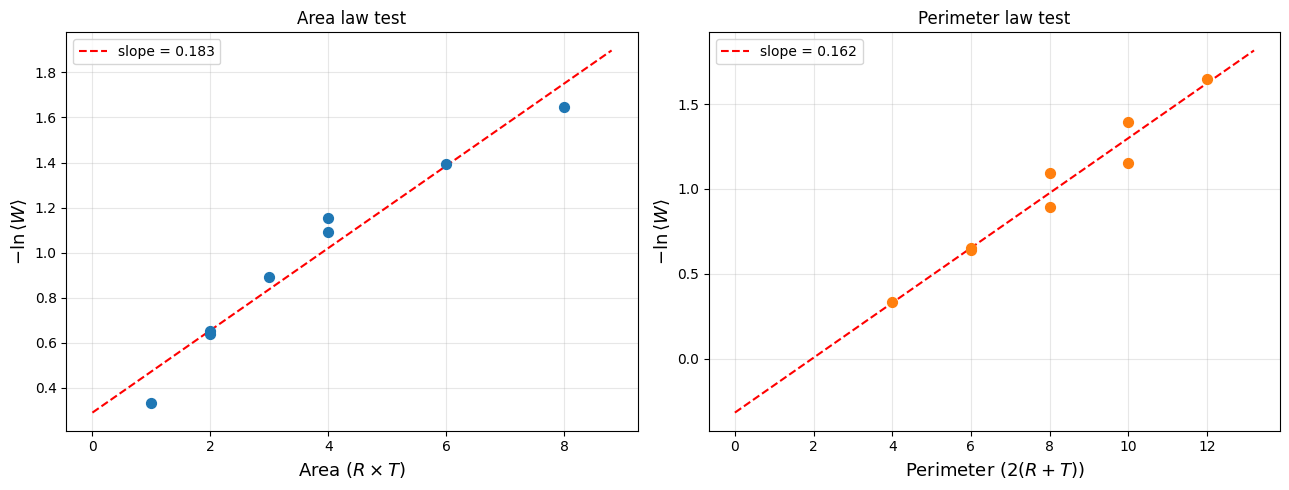

If the area law fits better (higher R^2), quarks are confined.
If the perimeter law fits better, quarks are deconfined.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

areas = []
perimeters = []
neg_log_W = []

for R in range(1, R_max + 1):
    for T in range(1, T_max + 1):
        w = W_vals[R-1, T-1]
        if w > 0:
            areas.append(R * T)
            perimeters.append(2 * (R + T))
            neg_log_W.append(-np.log(w))

areas = np.array(areas)
perimeters = np.array(perimeters)
neg_log_W = np.array(neg_log_W)

# vs Area
ax1.scatter(areas, neg_log_W, s=50, zorder=5)
if len(areas) > 1:
    c_area = np.polyfit(areas, neg_log_W, 1)
    x_fit = np.linspace(0, max(areas)*1.1, 50)
    ax1.plot(x_fit, np.polyval(c_area, x_fit), 'r--',
             label=f'slope = {c_area[0]:.3f}')
ax1.set_xlabel('Area ($R \\times T$)', fontsize=13)
ax1.set_ylabel('$-\\ln\\langle W \\rangle$', fontsize=13)
ax1.set_title('Area law test')
ax1.legend()
ax1.grid(True, alpha=0.3)

# vs Perimeter
ax2.scatter(perimeters, neg_log_W, s=50, zorder=5, color='C1')
if len(perimeters) > 1:
    c_perim = np.polyfit(perimeters, neg_log_W, 1)
    x_fit = np.linspace(0, max(perimeters)*1.1, 50)
    ax2.plot(x_fit, np.polyval(c_perim, x_fit), 'r--',
             label=f'slope = {c_perim[0]:.3f}')
ax2.set_xlabel('Perimeter ($2(R+T)$)', fontsize=13)
ax2.set_ylabel('$-\\ln\\langle W \\rangle$', fontsize=13)
ax2.set_title('Perimeter law test')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("If the area law fits better (higher R^2), quarks are confined.")
print("If the perimeter law fits better, quarks are deconfined.")

## 6. String Tension and Physical Scales

The string tension $\sigma$ has dimensions of (energy/length) = (mass)$^2$
in natural units. In physical QCD:

$$\sigma \approx (440\;\text{MeV})^2 \approx 0.19\;\text{GeV}^2$$

This means it takes about 1 GeV of energy to separate quarks by 1 fm.
At some point it becomes energetically favorable to create a new
quark-antiquark pair from the vacuum — **string breaking**.

Because $\sigma$ is dimensionful, the lattice extracts $\hat\sigma = \sigma a^2$
and one converts to physical units by setting the scale via a known
observable (High Energy Physics Essentials §10.4, Eqs. 10.129–10.130). Historically the
string tension itself was used as the scale-setting input — see Creutz
Ch. 22 for the original measurements via the Creutz ratio
$\chi(I,J) = -\ln\bigl[W(I,J)W(I-1,J-1)/W(I-1,J)W(I,J-1)\bigr]$
(High Energy Physics Essentials Eq. 10.49); Sommer, *Scale setting in lattice QCD*,
discusses the move to a force-derived scale $r_0$ with smaller systematic
uncertainties, and modern calculations use $w_0$/$t_0$ from the
Yang–Mills gradient flow (Korzec, *Introduction to Scale Setting in QCD*).

On our small $4^4$ lattice, we can only see a rough trend. Larger lattices
and ensemble averaging (as in the `wilson_loops.py` module for SU(3))
give much cleaner signals.

## Exercises

1. **Measure $W(R,T)$ at different $\beta$**: Repeat the Wilson loop
   calculation at $\beta = 1.5$ and $\beta = 4.0$. How does the string
   tension change? At weak coupling ($\beta \to \infty$), the string
   tension should vanish (perturbative regime).

2. **Creutz ratios**: The Creutz ratio
   $\chi(R,T) = -\ln\frac{W(R,T) W(R-1,T-1)}{W(R,T-1) W(R-1,T)}$
   cancels perimeter contributions and directly estimates $\sigma$.
   Compute $\chi(R,T)$ from your Wilson loop data.

3. **Compare SU(2) string tension to known results**: At $\beta = 2.4$
   for SU(2), published lattice results give $\sigma a^2 \approx 0.07$.
   How does your single-config measurement compare?
   What would improve the precision?